[0. 1.]
1


 1


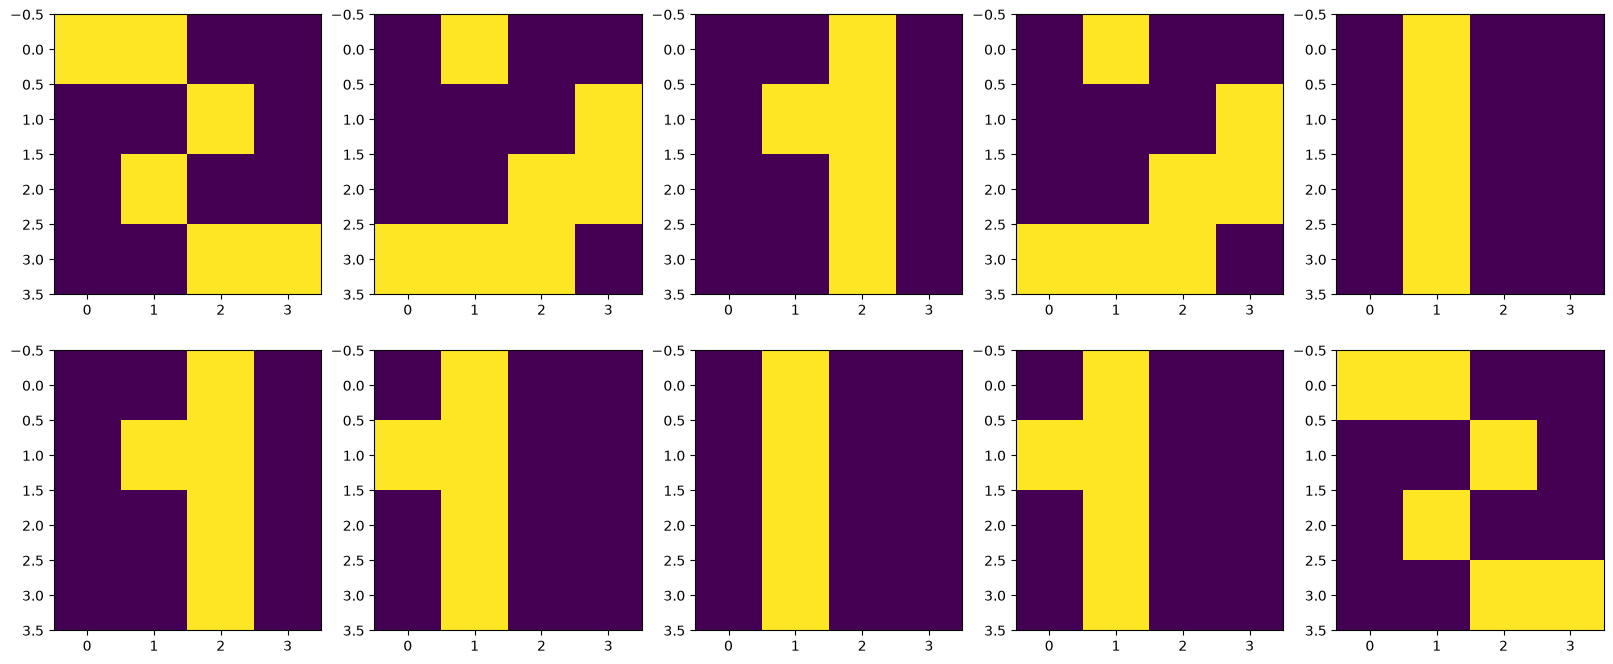

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(1)
def relu(x):
    return (x > 0) * x
def relu2deriv(out):
    return out > 0
data = np.array([[0, 0, 0, 1,
                  0, 0, 1, 1,
                  0, 0, 0, 1,
                  0, 0, 0, 1],
                 [0, 0, 0, 1,
                  0, 0, 0, 1,
                  0, 0, 0, 1,
                  0, 0, 0, 1],
                 [0, 0, 1, 0,
                  0, 1, 1, 0,
                  0, 0, 1, 0,
                  0, 0, 1, 0],
                 [0, 0, 1, 0,
                  0, 0, 1, 0,
                  0, 0, 1, 0,
                  0, 0, 1, 0],
                 [0, 1, 0, 0,
                  0, 1, 0, 0,
                  0, 1, 0, 0,
                  0, 1, 0, 0],
                 [0, 1, 0, 0,
                  1, 1, 0, 0,
                  0, 1, 0, 0,
                  0, 1, 0, 0],
                 [0, 0, 1, 0,
                  0, 1, 0, 1,
                  0, 1, 0, 1,
                  0, 0, 1, 0],
                 [0, 1, 0, 0,
                  1, 0, 1, 0,
                  1, 0, 1, 0,
                  0, 1, 0, 0],
                 [1, 0, 0, 0,
                  1, 0, 0, 0,
                  1, 0, 0, 0,
                  1, 0, 0, 0],
                 [0, 1, 0, 0,
                  1, 1, 0, 0,
                  0, 1, 0, 0,
                  1, 1, 1, 0],
                 [0, 0, 1, 0,
                  0, 1, 1, 0,
                  0, 0, 1, 0,
                  0, 1, 1, 1],
                 [0, 0, 0, 0,
                  0, 0, 1, 0,
                  0, 1, 0, 1,
                  0, 0, 1, 0],
                 [0, 1, 0, 0,
                  1, 0, 1, 0,
                  0, 1, 0, 0,
                  0, 0, 0, 0],
                 [0, 0, 0, 0,
                  0, 1, 0, 0,
                  1, 0, 1, 0,
                  0, 1, 0, 0],
                 [0, 0, 1, 0,
                  0, 1, 0, 1,
                  0, 0, 1, 0,
                  0, 0, 0, 0],
                 [0, 1, 1, 1,
                  0, 1, 0, 1,
                  0, 1, 1, 1,
                  0, 0, 0, 0],
                 [1, 1, 1, 0,
                  1, 0, 1, 0,
                  1, 1, 1, 0,
                  0, 0, 0, 0],
                 [0, 0, 0, 0,
                  0, 1, 1, 1,
                  0, 1, 0, 1,
                  0, 1, 1, 1],
                 [0, 0, 0, 0,
                  1, 1, 1, 0,
                  1, 0, 1, 0,
                  1, 1, 1, 0],
                 [0, 1, 1, 1,
                  0, 1, 0, 1,
                  0, 1, 0, 1,
                  0, 1, 1, 1],
                 [1, 1, 1, 0,
                  1, 0, 1, 0,
                  1, 0, 1, 0,
                  1, 1, 1, 0]])
tr = np.array([[0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0]])
a = 0.005
h1 = 500
w01 = 2 * np.random.random((16, h1)) - 1
w12 = 2 * np.random.random((h1, 2)) - 1
for i in range(100):
    for j in range(len(data)):
        l0 = data[j:j+1]
        l1 = relu(np.dot(l0, w01))
        l2 = np.dot(l1, w12)
        l2d = (l2 - tr[j:j+1])
        l1d = l2d.dot(w12.T)
        l1d *= relu2deriv(l1)
        wd12 = l1.T.dot(l2d)
        wd01 = l0.T.dot(l1d)
        w12 -= a * wd12
        w01 -= a * wd01
l0 = np.array([0, 0, 1, 0,
               0, 0, 1, 0,
               0, 0, 1, 0,
               0, 0, 1, 0])
l1 = relu(np.dot(l0, w01))
print(np.round(np.dot(l1, w12), decimals=2))
pred = np.dot(l1, w12)
ii = 0
ma = -10000
for i in range(len(pred)):
    if (pred[i] > ma):
        ma = pred[i]
        ii = i
print(ii)
def gener(q):
    a = []
    for i in range(q):
        a.append(random.randint(0, 1))
    b = []
    b.append(a)
    return np.array(b)
def whatnum(w):
    if (w[0][0] > w[0][1] and w[0][0] >= 1):
        return 0
    elif (w[0][1] > w[0][0] and w[0][1] >= 1):
        return 1
    else:
        return 2
c = int(input())
d = 0
fig, ax = plt.subplots(nrows = 2, ncols = 5, figsize=(20, 8))
ax = ax.flatten()
def ggwp(x):
    for i in range(len(x) - 1):
        c = 0
        for j in range(len(x)):
            c += x[i][j]
        if (c >= 3):
            return 0
    return 1
def what(x):
    if (x[0][0] == x[0][1] and x[0][0] == x[0][2] and x[0][0] == x[0][3]):
        return 0
    if (x[len(x) - 1][0] == x[len(x) - 1][1] and x[len(x) - 1][0] == x[len(x) - 1][2] and x[len(x) - 1][0] == x[len(x) - 1][3]):
        return 0
    for i in range(1, len(x) - 1):
        for j in range(1, len(x) - 1):
            if (x[i][j] == x[i][j - 1] and x[i][j] == x[i][j + 1] and x[i][j] == x[i - 1][j] and x[i][j] == x[i + 1][j]):
                return 0
        if (x[i][0] == x[i][1] and x[i][0] == x[i][2] and x[i][0] == x[i][3]):
            return 0
    return 1
while (d < 10):
    q = gener(16)
    q = q[0:1]
    l1 = relu(np.dot(q, w01))
    w = np.round(np.dot(l1, w12), decimals=2)
    g = whatnum(w)
    q = q.reshape(4, 4)
    if (g == c and (w[0][0] - 0 + w[0][1] - 1)**2 <= 0.00000001 and what(q) == 1 and ggwp(q) == 1):
        im = ax[d].imshow(q, cmap = 'viridis', aspect = 'auto')
        d += 1
plt.show()

In [1]:
import numpy as np
def sigm(x):
    return 1 / (1 + np.exp(-x))
def softma(x):
    return np.exp(x)/np.sum(np.exp(x), axis = 1, keepdims = True)
def deriv(x):
    return x * (1 - x)
inp = np.array([[0, 0, 0, 1,
                  0, 0, 1, 1,
                  0, 0, 0, 1,
                  0, 0, 0, 1],
                 [0, 0, 0, 1,
                  0, 0, 0, 1,
                  0, 0, 0, 1,
                  0, 0, 0, 1],
                 [0, 0, 1, 0,
                  0, 1, 1, 0,
                  0, 0, 1, 0,
                  0, 0, 1, 0],
                 [0, 0, 1, 0,
                  0, 0, 1, 0,
                  0, 0, 1, 0,
                  0, 0, 1, 0],
                 [0, 1, 0, 0,
                  0, 1, 0, 0,
                  0, 1, 0, 0,
                  0, 1, 0, 0],
                 [0, 1, 0, 0,
                  1, 1, 0, 0,
                  0, 1, 0, 0,
                  0, 1, 0, 0],
                 [0, 0, 1, 0,
                  0, 1, 0, 1,
                  0, 1, 0, 1,
                  0, 0, 1, 0],
                 [0, 1, 0, 0,
                  1, 0, 1, 0,
                  1, 0, 1, 0,
                  0, 1, 0, 0],
                 [1, 0, 0, 0,
                  1, 0, 0, 0,
                  1, 0, 0, 0,
                  1, 0, 0, 0],
                 [0, 1, 0, 0,
                  1, 1, 0, 0,
                  0, 1, 0, 0,
                  1, 1, 1, 0],
                 [0, 0, 1, 0,
                  0, 1, 1, 0,
                  0, 0, 1, 0,
                  0, 1, 1, 1],
                 [0, 0, 0, 0,
                  0, 0, 1, 0,
                  0, 1, 0, 1,
                  0, 0, 1, 0],
                 [0, 1, 0, 0,
                  1, 0, 1, 0,
                  0, 1, 0, 0,
                  0, 0, 0, 0],
                 [0, 0, 0, 0,
                  0, 1, 0, 0,
                  1, 0, 1, 0,
                  0, 1, 0, 0],
                 [0, 0, 1, 0,
                  0, 1, 0, 1,
                  0, 0, 1, 0,
                  0, 0, 0, 0],
                 [0, 1, 1, 1,
                  0, 1, 0, 1,
                  0, 1, 1, 1,
                  0, 0, 0, 0],
                 [1, 1, 1, 0,
                  1, 0, 1, 0,
                  1, 1, 1, 0,
                  0, 0, 0, 0],
                 [0, 0, 0, 0,
                  0, 1, 1, 1,
                  0, 1, 0, 1,
                  0, 1, 1, 1],
                 [0, 0, 0, 0,
                  1, 1, 1, 0,
                  1, 0, 1, 0,
                  1, 1, 1, 0],
                 [0, 1, 1, 1,
                  0, 1, 0, 1,
                  0, 1, 0, 1,
                  0, 1, 1, 1],
                 [1, 1, 1, 0,
                  1, 0, 1, 0,
                  1, 0, 1, 0,
                  1, 1, 1, 0]])
g = np.array([[0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0]])
def get_img(l, rf, rt, cf, ct):
    sub = l[:, rf:rt, cf:ct]
    return sub.reshape(-1, 1, rt-rf, ct-cf)
batch = 3
img = inp.reshape(-1, 4, 4)
lab = g
np.random.seed(1)
a = 0.005
kr = 2
kc = 2
nk = 8
kernels = 0.2 * np.random.random((kr * kc, nk)) - 0.1
inpr = 4
inpc = 4
orow = inpr - kr + 1
ocol = inpc - kc + 1
h = orow * ocol * nk
w12 = 0.2 * np.random.random((h, 2)) - 0.1
for i in range(500):
    for j in range(int(len(img)/batch)):
        bs = j * batch
        be = bs + batch
        l0 = img[bs:be]

        sects = list()
        for r in range(orow):
            for c in range(ocol):
                sect = get_img(l0, r, r + kr, c, c + kc)
                sects.append(sect)
        l0_resh = np.concatenate(sects, axis = 1)
        l0_flat = l0_resh.reshape(-1, kr * kc)
        ko = l0_flat.dot(kernels)
        l1 = sigm(ko.reshape(batch, -1))
        l2 = softma(l1.dot(w12))
        bat_lab = lab[bs:be]
        l2d = (bat_lab - l2)/batch
        l1d = l2d.dot(w12.T) * deriv(l1)
        w12 += a * l1.T.dot(l2d)
        l1d_resh = l1d.reshape(-1, nk)
        kernels += a * l0_flat.T.dot(l1d_resh)
bs = 6 * batch
be = bs + batch
l0 = img[bs:be]
sects = list()
for r in range(orow):
    for c in range(ocol):
        sect = get_img(l0, r, r + kr, c, c + kc)
        sects.append(sect)
l0_resh = np.concatenate(sects, axis = 1)
l0_flat = l0_resh.reshape(-1, kr * kc)
ko = l0_flat.dot(kernels)
l1 = sigm(ko.reshape(batch, -1))
l2 = softma(l1.dot(w12))
bat_lab = lab[bs:be]
print(l2)

[[0.61158851 0.38841149]
 [0.60580542 0.39419458]
 [0.60894798 0.39105202]]


1.7647641670832697 0
1.034745585937527 1000
1.0180035662834375 2000
1.0135476697000745 3000
1.0112013314394999 4000
1.0094308066591313 5000
1.0078515447863217 6000
1.0063322150393677 7000
1.0048167808614092 8000
1.003276545096224 9000
1.001694151092405 10000
1.0000573723884343 11000
0.9983564121195722 12000
0.9965826176910431 13000
0.9947278205731557 14000
0.9927839730470203 15000
0.9907429346564938 16000
0.9885963379944311 17000
0.9863354983994909 18000
0.9839513489681404 19000
0.9814343908061892 20000
0.9787746529574319 21000
0.9759616589429827 22000
0.9729843982880064 23000
0.9698313022888815 24000
0.9664902238380496 25000
0.9629484215134095 26000
0.9591925484303764 27000
0.9552086465909029 28000
0.9509821476695567 29000
0.9464978813659825 30000
0.9417400926329087 31000
0.9366924692618654 32000
0.9313381814742485 33000
0.9256599353197009 34000
0.9196400418209038 35000
0.9132605039149093 36000
0.9065031233148045 37000
0.8993496294373313 38000
0.8917818324953464 39000
0.88378180271842

 1


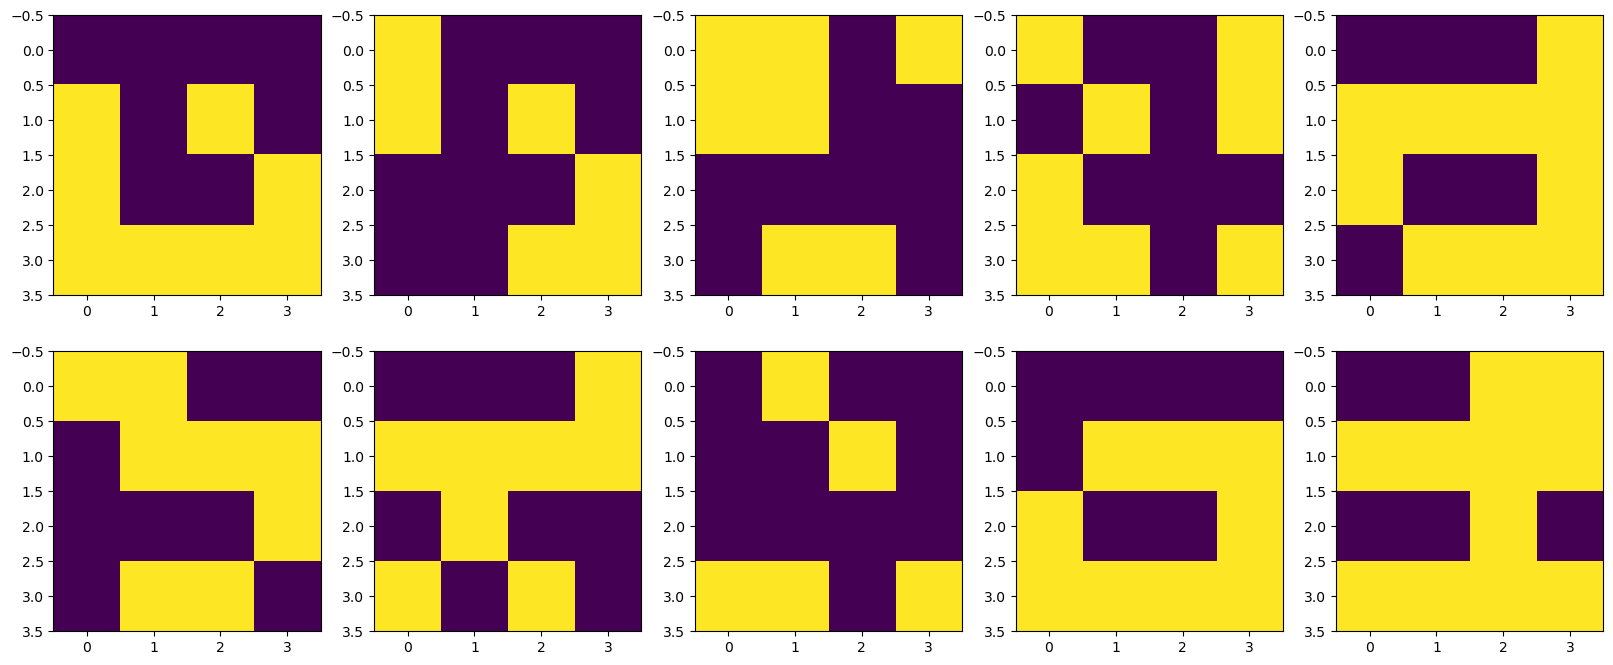

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline
def sigm(x):
    return 1 / (1 + np.exp(-x))
def softma(x):
    return np.exp(x)/np.sum(np.exp(x), axis = 1, keepdims = True)
def deriv(x):
    return x * (1 - x)
def gener(q):
    a = []
    for i in range(q):
        a.append(random.randint(0, 1))
    b = []
    b.append(a)
    return np.array(b)
inp = np.array([[0, 0, 0, 1,
                  0, 0, 1, 1,
                  0, 0, 0, 1,
                  0, 0, 1, 1],
                 [0, 0, 1, 0,
                  0, 1, 1, 0,
                  0, 0, 1, 0,
                  0, 1, 1, 1],
                 [0, 1, 0, 0,
                  1, 1, 0, 0,
                  0, 1, 0, 0,
                  1, 1, 1, 0],
                 [0, 0, 1, 0,
                  0, 1, 0, 1,
                  0, 1, 0, 1,
                  0, 0, 1, 0],
                 [0, 1, 0, 0,
                  1, 0, 1, 0,
                  1, 0, 1, 0,
                  0, 1, 0, 0],
                 [0, 1, 0, 0,
                  1, 1, 0, 0,
                  0, 1, 0, 0,
                  1, 1, 1, 0],
                 [0, 0, 1, 0,
                  0, 1, 1, 0,
                  0, 0, 1, 0,
                  0, 1, 1, 1],
                 [0, 1, 1, 1,
                  0, 1, 0, 1,
                  0, 1, 0, 1,
                  0, 1, 1, 1],
                 [1, 1, 1, 0,
                  1, 0, 1, 0,
                  1, 0, 1, 0,
                  1, 1, 1, 0]])
g = np.array([[0, 1, 0], [0, 1, 0], [0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 1, 0], [0, 1, 0], [1, 0, 0], [1, 0, 0]])
for ok in range(50):
    np.append(inp, gener(16))
    np.append(g, [0, 0, 1])
tinp = np.array([[1, 1, 1, 1,
                  1, 0, 0, 1,
                  1, 0, 0, 1,
                  1, 1, 1, 1],
                 [0, 0, 1, 0,
                  0, 1, 1, 0,
                  0, 0, 1, 0,
                  0, 0, 1, 0]])
tg = np.array([[1, 0, 0], [0, 1, 0]])
def get_img(l, rf, rt, cf, ct):
    sub = l[:, rf:rt, cf:ct]
    return sub.reshape(-1, 1, rt-rf, ct-cf)
batch = 1
img = inp.reshape(-1, 4, 4)
timg = tinp.reshape(-1, 4, 4)
lab = g
np.random.seed(1)
a = 0.00005
kr = 2
kc = 2
nk = 8
kernels = 0.2 * np.random.random((kr * kc, nk)) - 0.1
inpr = 4
inpc = 4
orow = inpr - kr + 1
ocol = inpc - kc + 1
h = orow * ocol * nk
w12 = 0.2 * np.random.random((h, 3)) - 0.1
for i in range(1000000):
    for j in range(int(len(img)/batch)):
        bs = j * batch
        be = bs + batch
        l0 = img[bs:be]
        sects = list()
        for r in range(orow):
            for c in range(ocol):
                sect = get_img(l0, r, r + kr, c, c + kc)
                sects.append(sect)
        l0_resh = np.concatenate(sects, axis = 1)
        l0_flat = l0_resh.reshape(-1, kr * kc)
        ko = l0_flat.dot(kernels)
        l1 = sigm(ko.reshape(batch, -1))
        l2 = softma(l1.dot(w12))
        bat_lab = lab[bs:be]
        l2d = (bat_lab - l2)/batch
        l1d = l2d.dot(w12.T) * deriv(l1)
        w12 += a * l1.T.dot(l2d)
        l1d_resh = l1d.reshape(-1, nk)
        kernels += a * l0_flat.T.dot(l1d_resh)
    if (i%1000 == 0):
        err = 0
        for k in range(int(len(tg)/batch)):
            bs = k * batch
            be = bs + batch
            l0 = timg[bs:be]
    
            sects = list()
            for r in range(orow):
                for c in range(ocol):
                    sect = get_img(l0, r, r + kr, c, c + kc)
                    sects.append(sect)
            l0_resh = np.concatenate(sects, axis = 1)
            l0_flat = l0_resh.reshape(-1, kr * kc)
            ko = l0_flat.dot(kernels)
            l1 = sigm(ko.reshape(batch, -1))
            l2 = softma(l1.dot(w12))
            for ki in range(len(l2[0])):
                err += (l2[0][ki] - tg[k][ki])**2
        print(err, i)
    '''if (i%10 == 0):
        print(np.round(err, 2))'''
bs = 0 * batch
be = bs + batch
l0 = img[bs:be]
sects = list()
for r in range(orow):
    for c in range(ocol):
        sect = get_img(l0, r, r + kr, c, c + kc)
        sects.append(sect)
l0_resh = np.concatenate(sects, axis = 1)
l0_flat = l0_resh.reshape(-1, kr * kc)
ko = l0_flat.dot(kernels)
l1 = sigm(ko.reshape(batch, -1))
l2 = softma(l1.dot(w12))
bat_lab = lab[bs:be]
print(l2)
c = int(input())
d = 0
fig, ax = plt.subplots(nrows = 2, ncols = 5, figsize=(20, 8))
ax = ax.flatten()
while (d < 10):
    q = gener(16)
    q = q.reshape(-1, 4, 4)
    l0 = q[0:1]
    sects = list()
    for r in range(orow):
        for cc in range(ocol):
            sect = get_img(l0, r, r + kr, cc, cc + kc)
            sects.append(sect)
    l0_resh = np.concatenate(sects, axis = 1)
    l0_flat = l0_resh.reshape(-1, kr * kc)
    ko = l0_flat.dot(kernels)
    l1 = sigm(ko.reshape(batch, -1))
    l2 = softma(l1.dot(w12))
    bat_lab = lab[bs:be]
    z = 0
    o = 0
    z += l2[0][0]
    o += l2[0][1]
    if (z > o and c == 0 and z > l2[0][2] and z > 0.99):
        im = ax[d].imshow(q[0], cmap = 'viridis', aspect = 'auto')
        d += 1
    elif (o > z and c == 1 and o > l2[0][2] and o > 0.99):
        im = ax[d].imshow(q[0], cmap = 'viridis', aspect = 'auto')
        d += 1
plt.show()

 0


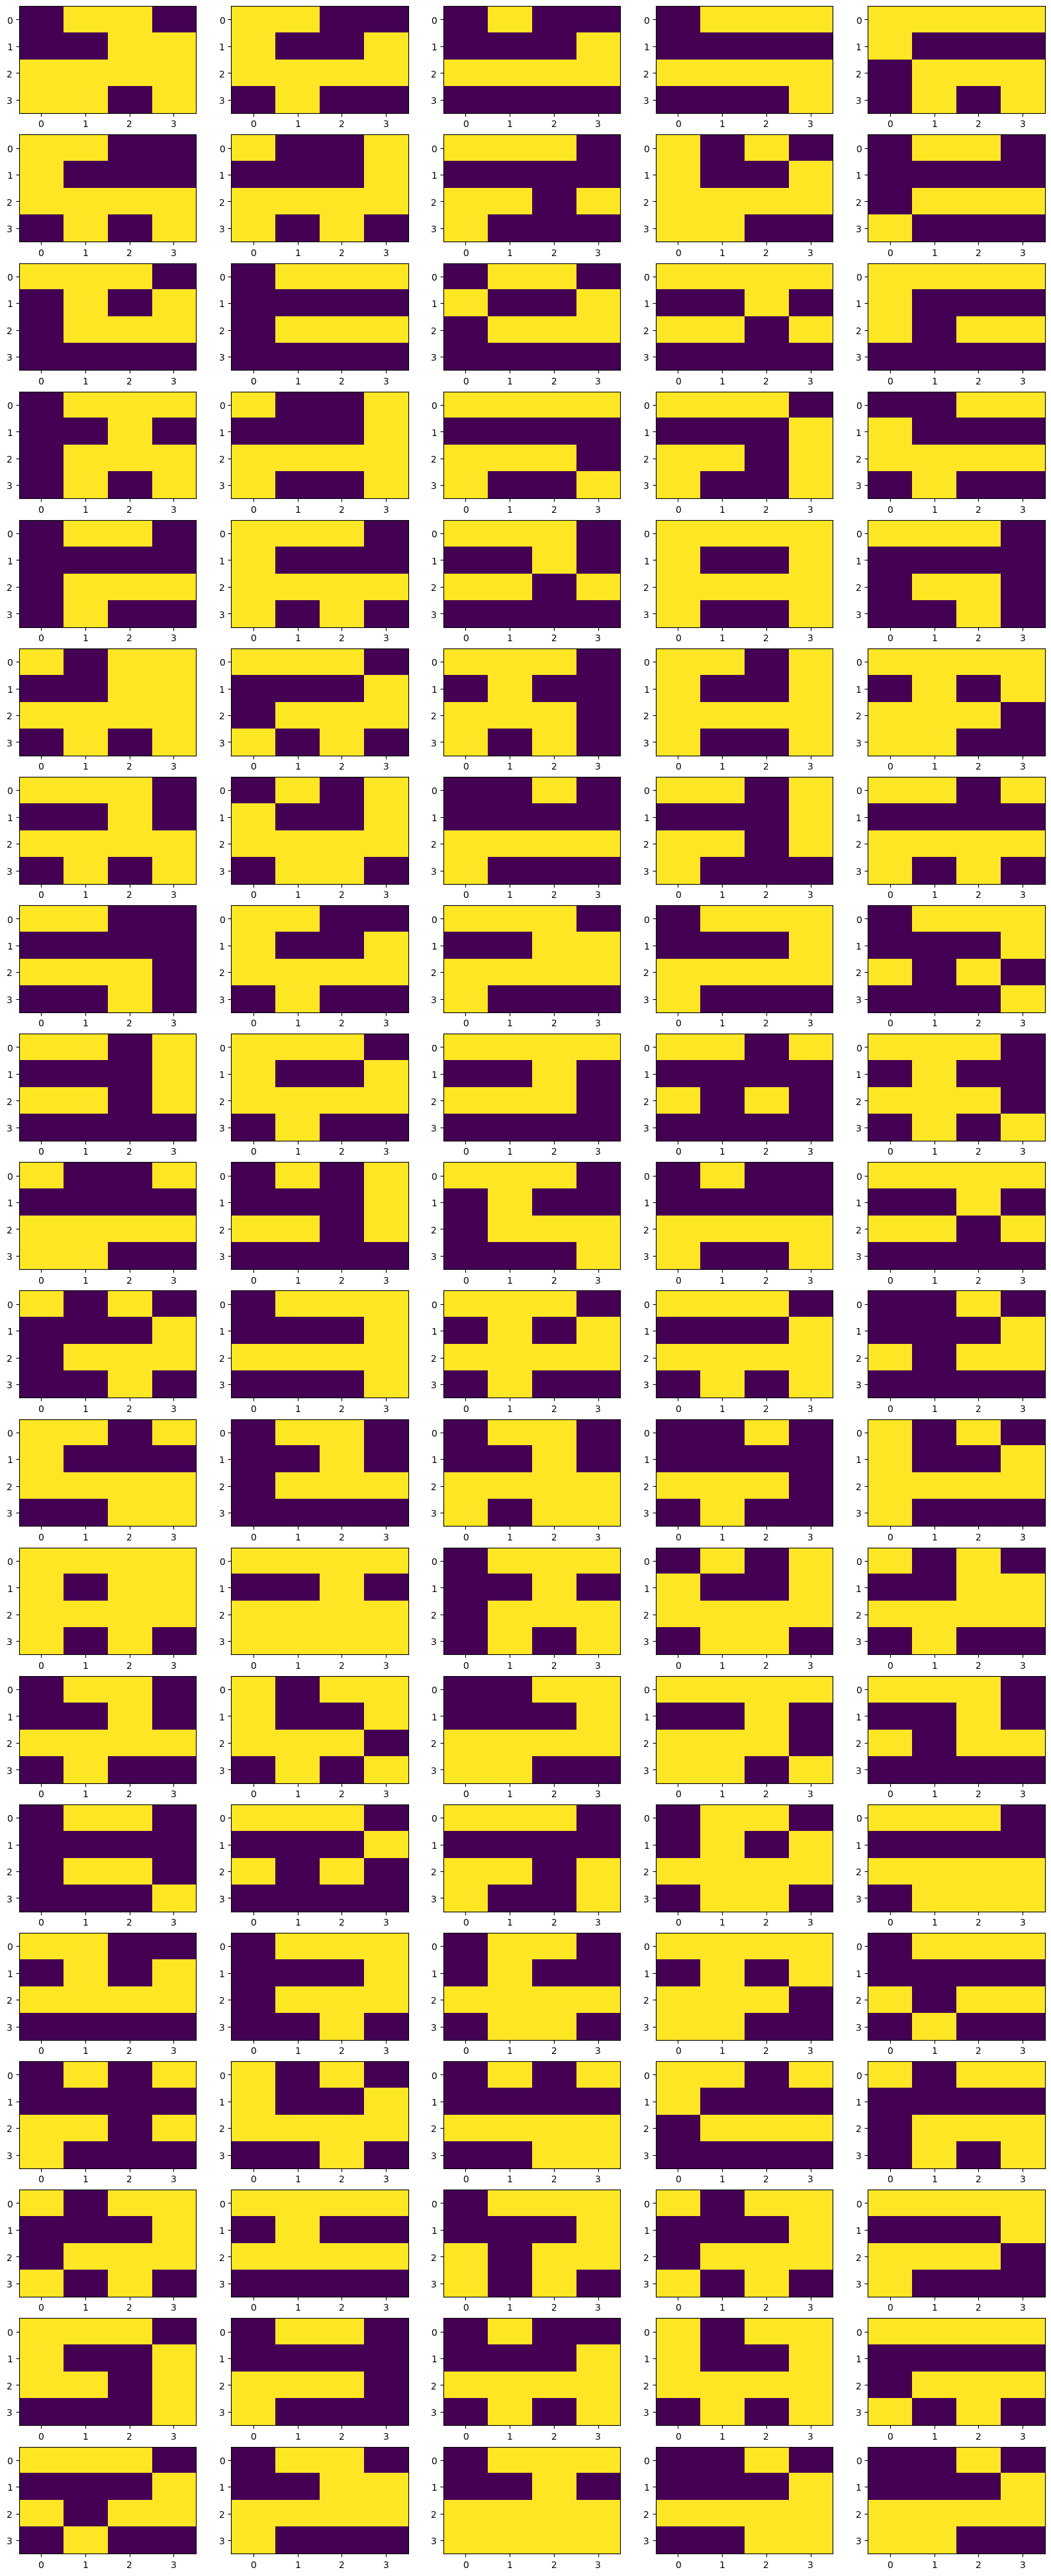

In [5]:
c = int(input())
d = 0
fig, ax = plt.subplots(nrows = 20, ncols = 5, figsize=(20, 50))
ax = ax.flatten()
while (d < 100):
    q = gener(16)
    q = q.reshape(-1, 4, 4)
    l0 = q[0:1]
    sects = list()
    for r in range(orow):
        for cc in range(ocol):
            sect = get_img(l0, r, r + kr, cc, cc + kc)
            sects.append(sect)
    l0_resh = np.concatenate(sects, axis = 1)
    l0_flat = l0_resh.reshape(-1, kr * kc)
    ko = l0_flat.dot(kernels)
    l1 = sigm(ko.reshape(batch, -1))
    l2 = softma(l1.dot(w12))
    bat_lab = lab[bs:be]
    z = 0
    o = 0
    z += l2[0][0]
    o += l2[0][1]
    if (z > o and c == 0 and z > l2[0][2] and z > 0.996 and l2[0][2] < 10 ** (-7)):
        im = ax[d].imshow(q[0], cmap = 'viridis', aspect = 'auto')
        d += 1
    elif (o > z and c == 1 and o > l2[0][2] and o > 0.996 and l2[0][2] < 10 ** (-7)):
        im = ax[d].imshow(q[0], cmap = 'viridis', aspect = 'auto')
        d += 1
plt.show()

 0


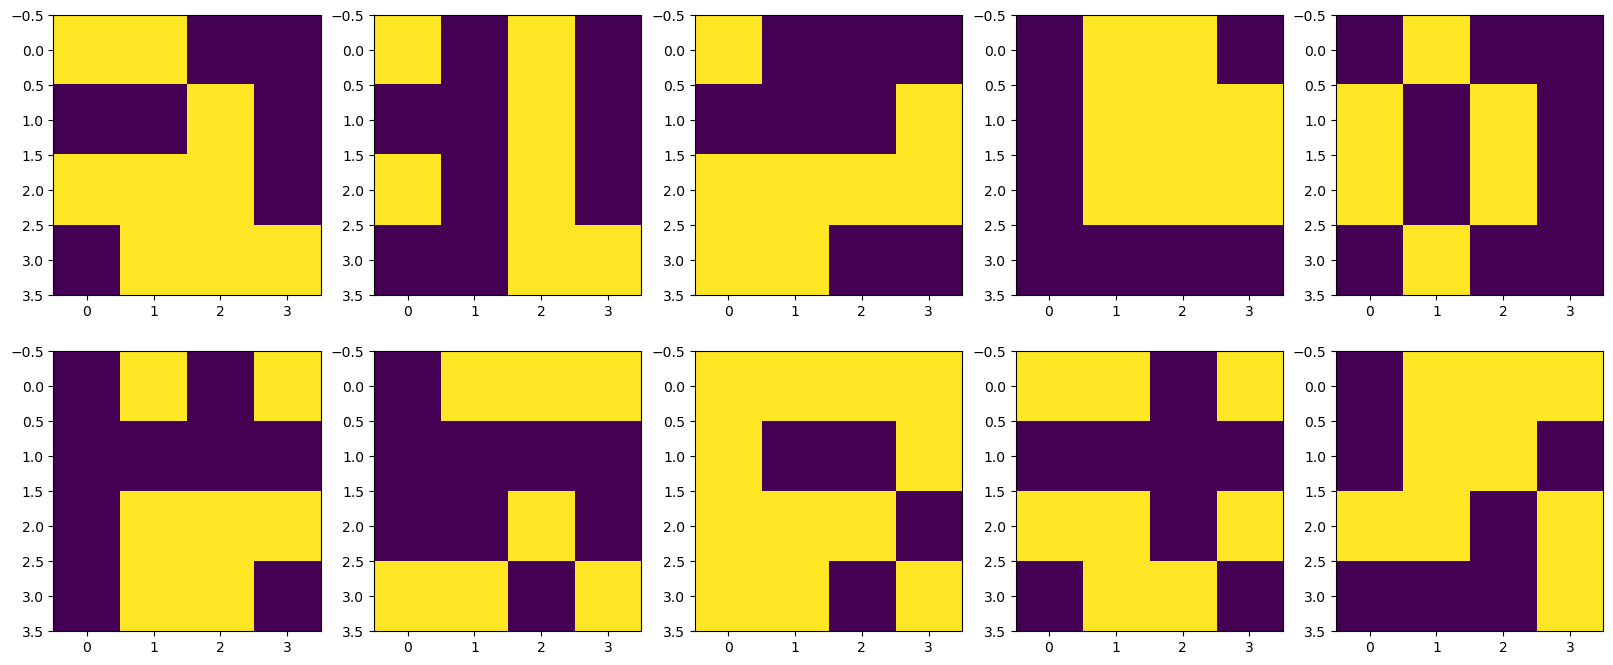

2


In [4]:
c = int(input())
d = 0
fig, ax = plt.subplots(nrows = 2, ncols = 5, figsize=(20, 8))
ax = ax.flatten()
while (d < 10):
    q = gener(16)
    q = q.reshape(-1, 4, 4)
    l0 = q[0:1]
    sects = list()
    for r in range(orow):
        for cc in range(ocol):
            sect = get_img(l0, r, r + kr, cc, cc + kc)
            sects.append(sect)
    l0_resh = np.concatenate(sects, axis = 1)
    l0_flat = l0_resh.reshape(-1, kr * kc)
    ko = l0_flat.dot(kernels)
    l1 = sigm(ko.reshape(batch, -1))
    l2 = softma(l1.dot(w12))
    bat_lab = lab[bs:be]
    z = 0
    o = 0
    z += l2[0][0]
    o += l2[0][1]
    if (z > o and c == 0 and z > l2[0][2] and z > 0.999995):
        im = ax[d].imshow(q[0], cmap = 'viridis', aspect = 'auto')
        d += 1
    elif (o > z and c == 1 and o > l2[0][2] and o > 0.999995):
        im = ax[d].imshow(q[0], cmap = 'viridis', aspect = 'auto')
        d += 1
plt.show()
q = np.array([[0, 0, 1, 0],
              [0, 1, 1, 0],
              [0, 0, 1, 0],
              [0, 1, 1, 1]])
q = gener(16)
q = q.reshape(-1, 4, 4)
l0 = q[0:1]
sects = list()
for r in range(orow):
    for cc in range(ocol):
        sect = get_img(l0, r, r + kr, cc, cc + kc)
        sects.append(sect)
l0_resh = np.concatenate(sects, axis = 1)
l0_flat = l0_resh.reshape(-1, kr * kc)
ko = l0_flat.dot(kernels)
l1 = sigm(ko.reshape(batch, -1))
l2 = softma(l1.dot(w12))
bat_lab = lab[bs:be]
z = 0
o = 0
z += l2[0][0]
o += l2[0][1]
if (z > o and c == 0 and z > l2[0][2] and z > 0.97):
    print(0)
elif (o > z and c == 1 and o > l2[0][2] and o > 0.97):
    print(1)
else:
    print(2)

1.9687591169571703 0
2.318359631269208 1000
2.2104146575678323 2000
2.1575766847285607 3000
2.12426655427328 4000
2.1006467646268185 5000
2.0827004938274083 6000
2.0684272214224686 7000
2.0566993766865127 8000
2.04682479438914 9000
2.0383510822170487 10000
2.0309679704188173 11000
2.024454373843497 12000
2.0186477820586686 13000
2.0134256178795025 14000
2.008693389542206 15000
2.0043768862772557 16000
2.000416878342516 17000
1.9967654220739912 18000
1.9933832242920122 19000
1.990237724144847 20000
1.987301671982269 21000
1.9845520595776887 22000
1.9819693032377037 23000
1.9795366119097715 24000
1.9772394926267878 25000
1.9750653592777303 26000
1.9730032200705054 27000
1.9710434256005913 28000
1.9691774640793234 29000
1.967397793609622 30000
1.9656977038229524 31000
1.9640712009772434 32000
1.962512911944842 33000
1.9610180035187763 34000
1.959582114224074 35000
1.9582012964016902 36000
1.9568719667807661 37000
1.9555908641038902 38000
1.9543550126434301 39000
1.9531616906627003 40000
1

 1


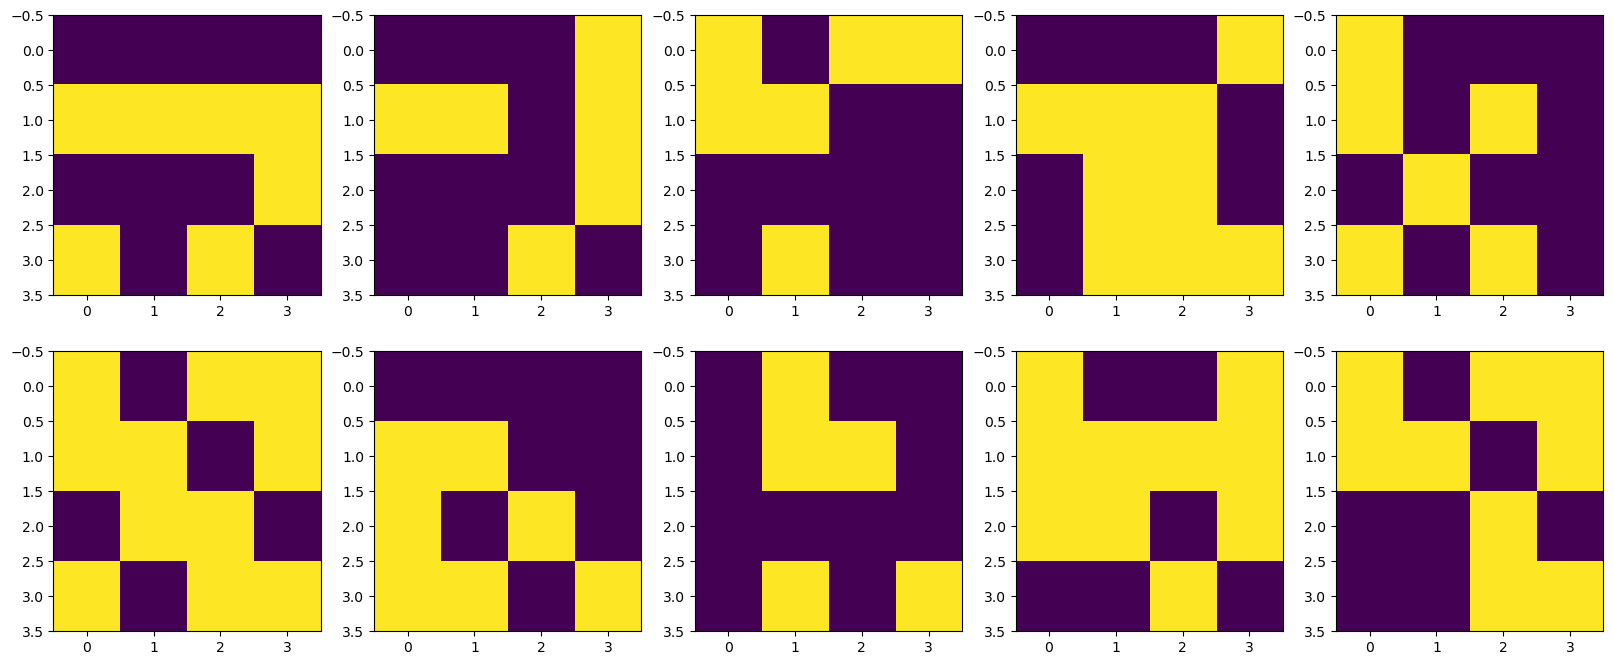

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline
def sigm(x):
    return 1 / (1 + np.exp(-x))
def softma(x):
    return np.exp(x)/np.sum(np.exp(x), axis = 1, keepdims = True)
def tanh(x):
    return np.tanh(x)
def deriv(x):
    return 1 - x**2
inp = np.array([[0, 0, 0, 1,
                  0, 0, 1, 1,
                  0, 0, 0, 1,
                  0, 0, 0, 1],
                 [0, 0, 1, 0,
                  0, 1, 1, 0,
                  0, 0, 1, 0,
                  0, 1, 1, 1],
                 [0, 1, 0, 0,
                  1, 1, 0, 0,
                  0, 1, 0, 0,
                  0, 1, 0, 0],
                 [0, 0, 1, 0,
                  0, 1, 0, 1,
                  0, 1, 0, 1,
                  0, 0, 1, 0],
                 [0, 1, 0, 0,
                  1, 0, 1, 0,
                  1, 0, 1, 0,
                  0, 1, 0, 0],
                 [0, 1, 0, 0,
                  1, 1, 0, 0,
                  0, 1, 0, 0,
                  1, 1, 1, 0],
                 [0, 0, 1, 0,
                  0, 1, 1, 0,
                  0, 0, 1, 0,
                  0, 1, 1, 1],
                 [0, 1, 1, 1,
                  0, 1, 0, 1,
                  0, 1, 0, 1,
                  0, 1, 1, 1],
                 [1, 1, 1, 0,
                  1, 0, 1, 0,
                  1, 0, 1, 0,
                  1, 1, 1, 0]])
g = np.array([[0, 1, 0], [0, 1, 0], [0, 1, 0], [1, 0, 0], [1, 0, 0], [0, 1, 0], [0, 1, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0]])
tinp = np.array([[1, 1, 1, 1,
                  1, 0, 0, 1,
                  1, 0, 0, 1,
                  1, 1, 1, 1],
                 [0, 0, 1, 0,
                  0, 1, 1, 0,
                  0, 0, 1, 0,
                  0, 0, 1, 0]])
tg = np.array([[1, 0, 0], [0, 1, 0]])
def get_img(l, rf, rt, cf, ct):
    sub = l[:, rf:rt, cf:ct]
    return sub.reshape(-1, 1, rt-rf, ct-cf)
batch = 1
img = inp.reshape(-1, 4, 4)
timg = tinp.reshape(-1, 4, 4)
lab = g
np.random.seed(1)
a = 0.05
kr = 2
kc = 2
nk = 8
kernels = 0.2 * np.random.random((kr * kc, nk)) - 0.1
inpr = 4
inpc = 4
orow = inpr - kr + 1
ocol = inpc - kc + 1
h = orow * ocol * nk
w12 = 0.2 * np.random.random((h, 3)) - 0.1
for i in range(500000):
    for j in range(int(len(img)/batch)):
        bs = j * batch
        be = bs + batch
        l0 = img[bs:be]
        sects = list()
        for r in range(orow):
            for c in range(ocol):
                sect = get_img(l0, r, r + kr, c, c + kc)
                sects.append(sect)
        l0_resh = np.concatenate(sects, axis = 1)
        l0_flat = l0_resh.reshape(-1, kr * kc)
        ko = l0_flat.dot(kernels)
        l1 = tanh(ko.reshape(batch, -1))
        l2 = softma(l1.dot(w12))
        bat_lab = lab[bs:be]
        l2d = (bat_lab - l2)/batch
        l1d = l2d.dot(w12.T) * deriv(l1)
        w12 += a * l1.T.dot(l2d)
        l1d_resh = l1d.reshape(-1, nk)
        kernels += a * l0_flat.T.dot(l1d_resh)
    if (i%1000 == 0):
        err = 0
        for k in range(int(len(tg)/batch)):
            bs = k * batch
            be = bs + batch
            l0 = timg[bs:be]
    
            sects = list()
            for r in range(orow):
                for c in range(ocol):
                    sect = get_img(l0, r, r + kr, c, c + kc)
                    sects.append(sect)
            l0_resh = np.concatenate(sects, axis = 1)
            l0_flat = l0_resh.reshape(-1, kr * kc)
            ko = l0_flat.dot(kernels)
            l1 = sigm(ko.reshape(batch, -1))
            l2 = softma(l1.dot(w12))
            for ki in range(len(l2[0])):
                err += (l2[0][ki] - tg[k][ki])**2
        print(err, i)
    '''if (i%10 == 0):
        print(np.round(err, 2))'''
bs = 0 * batch
be = bs + batch
l0 = img[bs:be]
sects = list()
for r in range(orow):
    for c in range(ocol):
        sect = get_img(l0, r, r + kr, c, c + kc)
        sects.append(sect)
l0_resh = np.concatenate(sects, axis = 1)
l0_flat = l0_resh.reshape(-1, kr * kc)
ko = l0_flat.dot(kernels)
l1 = sigm(ko.reshape(batch, -1))
l2 = softma(l1.dot(w12))
bat_lab = lab[bs:be]
print(l2)
def gener(q):
    a = []
    for i in range(q):
        a.append(random.randint(0, 1))
    b = []
    b.append(a)
    return np.array(b)
c = int(input())
d = 0
fig, ax = plt.subplots(nrows = 2, ncols = 5, figsize=(20, 8))
ax = ax.flatten()
while (d < 10):
    q = gener(16)
    q = q.reshape(-1, 4, 4)
    l0 = q[0:1]
    sects = list()
    for r in range(orow):
        for cc in range(ocol):
            sect = get_img(l0, r, r + kr, cc, cc + kc)
            sects.append(sect)
    l0_resh = np.concatenate(sects, axis = 1)
    l0_flat = l0_resh.reshape(-1, kr * kc)
    ko = l0_flat.dot(kernels)
    l1 = sigm(ko.reshape(batch, -1))
    l2 = softma(l1.dot(w12))
    bat_lab = lab[bs:be]
    z = 0
    o = 0
    z += l2[0][0]
    o += l2[0][1]
    if (z > o and c == 0 and z > l2[0][2] and z > 0.75):
        im = ax[d].imshow(q[0], cmap = 'viridis', aspect = 'auto')
        d += 1
    elif (o > z and c == 1 and o > l2[0][2] and o > 0.5):
        im = ax[d].imshow(q[0], cmap = 'viridis', aspect = 'auto')
        d += 1
plt.show()

In [ ]:
c = int(input())
d = 0
fig, ax = plt.subplots(nrows = 20, ncols = 5, figsize=(20, 50))
ax = ax.flatten()
while (d < 10):
    q = gener(16)
    q = q.reshape(-1, 4, 4)
    l0 = q[0:1]
    sects = list()
    for r in range(orow):
        for cc in range(ocol):
            sect = get_img(l0, r, r + kr, cc, cc + kc)
            sects.append(sect)
    l0_resh = np.concatenate(sects, axis = 1)
    l0_flat = l0_resh.reshape(-1, kr * kc)
    ko = l0_flat.dot(kernels)
    l1 = sigm(ko.reshape(batch, -1))
    l2 = softma(l1.dot(w12))
    bat_lab = lab[bs:be]
    z = 0
    o = 0
    z += l2[0][0]
    o += l2[0][1]
    if (z > o and c == 0 and z > l2[0][2] and z > 0.999995):
        im = ax[d].imshow(q[0], cmap = 'viridis', aspect = 'auto')
        d += 1
    elif (o > z and c == 1 and o > l2[0][2] and o > 0.999995):
        im = ax[d].imshow(q[0], cmap = 'viridis', aspect = 'auto')
        d += 1
plt.show()
q = np.array